In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score


le = LabelEncoder()
scaler = StandardScaler()

from sklearn.linear_model import LogisticRegression
log_reg_class = LogisticRegression()

a = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep = ';')

#Display summary statistics and check for missing values
print(a.head(10), a.describe(), sep = '\n')
a.info()

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   
5            7.4              0.66         0.00             1.8      0.075   
6            7.9              0.60         0.06             1.6      0.069   
7            7.3              0.65         0.00             1.2      0.065   
8            7.8              0.58         0.02             2.0      0.073   
9            7.5              0.50         0.36             6.1      0.071   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0

* There are no missing values in the dataset.
* The mean value of Citric Acid content is 0.271 g/dm³, and the mean quality of wines is 5.636. The 3rd quartile of Total Sulfur Dioxide content is 63 mg/dm³.
* If `quality=0` describes the worst wine in the dataset, then theoretically the best wine in the dataset should be a quality = 10 as defined by the provided description of the variable. However, the maximum quality in the data is only of quality = 8, so that is the best wine in the dataset.

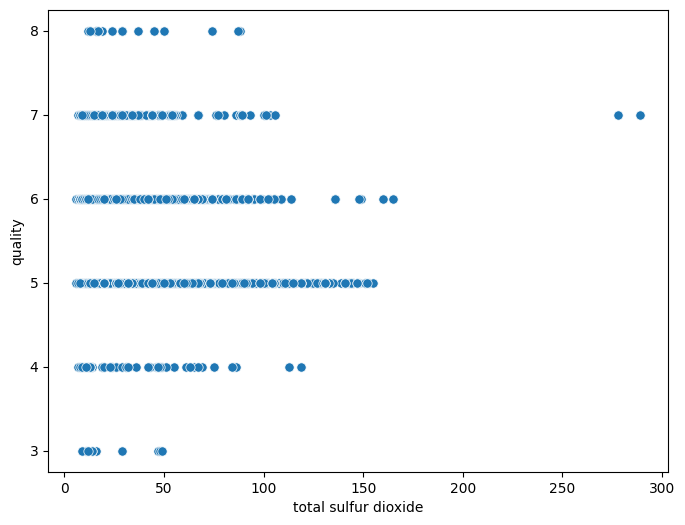

In [107]:
# build 2 graphs #total sulf dox vs quality
#total sulf dox vs quality

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter( a['total sulfur dioxide'], a['quality'], color='tab:blue', edgecolor='white', linewidths= 0.5, s=45)

# Set labels to match your image
plt.xlabel('total sulfur dioxide')
plt.ylabel('quality')

# Optional: Match the precise axis padding if needed
plt.margins(x=0.05, y=0.05)

plt.show()


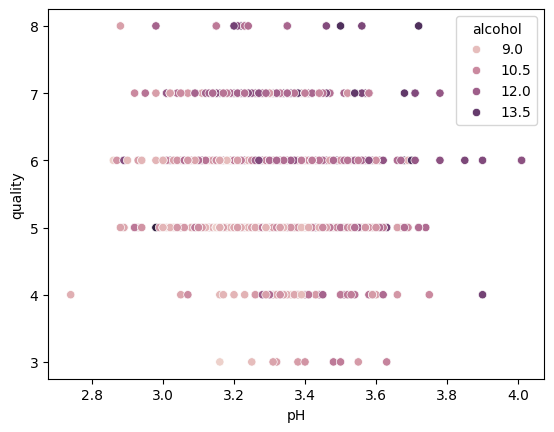

In [111]:
#ph vs quality
scatter, ax = plt.subplots()
ax = sns.scatterplot(x = "pH", y = "quality", data = a, hue = 'alcohol')

ax.set_xlabel("pH")
ax.set_ylabel("quality")
plt.show()

In [120]:
# ALWAYS SPLIT THEN SCALE
X = a.drop('quality', axis = 1).values
y = a['quality'].values

X_train,X_test,Y_train,Y_test = train_test_split(X, y, test_size=0.2)

sX_train = scaler.fit_transform(X_train)
sX_test = scaler.fit_transform(X_test)

* The alpha parameter is the constant usually in [0, 2] that is multiplied with the least square regression penalty to find error, .
* The l1 ratio is the amount of each kind of penality this model takes on, with values in [0, 1]. When l1 ration =< 0.5, we lean towards L2 penalty and when l1 ratio is >= 0.5, we lean towards L1 penalty.

In [136]:
# elastic net
Ereg = ElasticNet(alpha=1, l1_ratio=0.5, random_state=42)
Ereg.fit(sX_train,Y_train)
y_pred = Ereg.predict(sX_test)
mse = mean_squared_error(y_pred, Y_test)
r2 = r2_score(Y_test, y_pred)
print('the mse is', mse, 'and the r2 is', r2)


the mse is 0.6699754361823674 and the r2 is -0.0009554226010275446


In [142]:
# elastic net: trials with alpha 3, 0.5 and l1 ratio 0.25, 0.75
# found best one of the four being alpha = 0.5, l1ratio = 0.25
Ereg = ElasticNet(alpha=0.5, l1_ratio=0.25, random_state=42)
Ereg.fit(sX_train,Y_train)
y_pred = Ereg.predict(sX_test)
mse = mean_squared_error(y_pred, Y_test)
r2 = r2_score(Y_test, y_pred)
print('the mse is', mse, 'and the r2 is', r2)

the mse is 0.5315927102332242 and the r2 is 0.20579087353542236


In [151]:
#elastic net CV1
EregCV = ElasticNetCV(alphas=[0.01, 0.1, 1.0, 10.0], l1_ratio=[0.1, 0.25, 0.5, 0.75, 0.9], random_state=42)
EregCV.fit(sX_train,Y_train)
y_pred = EregCV.predict(sX_test)
mse = mean_squared_error(y_pred, Y_test)
r2 = r2_score(Y_test, y_pred)
print('the mse is', mse, 'and the r2 is', r2)

#elastic net CV2
EregCV = ElasticNetCV(alphas=100, l1_ratio=[0.1, 0.25, 0.5, 0.75, 0.9], random_state=42)
EregCV.fit(sX_train,Y_train)
y_pred = EregCV.predict(sX_test)
mse = mean_squared_error(y_pred, Y_test)
r2 = r2_score(Y_test, y_pred)
print('the mse is', mse, 'and the r2 is', r2)

the mse is 0.4886657480573483 and the r2 is 0.2699245316446971
the mse is 0.4880578680593852 and the r2 is 0.27083271535919107


Did using cross validation help in any way? Quantify the improvement or lack thereof.
*After manually attempting 4 values to better understand the data, I had a r2 value of 0.206 which is a weak value but showed improvement over the inital measure of alpha = 1, lratio = 0.5 at a r2 value of 0.001. 
*The cross validation helped increase the final r2 value to 0.271, but that is still a very weak value. Therefore, cross validation did help, but not as significantly as I would have hoped. It probably would be more worthwile to familiarize myself with the variables in visualizations and through other metrics before using cross validation.

##PART TWO: QUESTIONS

In [3]:
data = pd.read_csv('hearing_test.csv')
print(data.head(6), data.describe(), sep = '\n')
data.info()

    age  physical_score  test_result
0  33.0            40.7            1
1  50.0            37.2            1
2  52.0            24.7            0
3  56.0            31.0            0
4  35.0            42.9            1
5  58.0            23.0            0
               age  physical_score  test_result
count  5000.000000     5000.000000  5000.000000
mean     51.609000       32.760260     0.600000
std      11.287001        8.169802     0.489947
min      18.000000       -0.000000     0.000000
25%      43.000000       26.700000     0.000000
50%      51.000000       35.300000     1.000000
75%      60.000000       38.900000     1.000000
max      90.000000       50.000000     1.000000
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null

## Exploratory Data Analysis (EDA)
There are 5000 entries in this dataset, and the mean age of participants is 51.609 years; The oldest participant is 90 years old. The IQR of the physical score feature is Q3-Q1 = 38.9-26.7 = 12.2 points.
*The phrase 'data['test_result'].value_counts()' provides the number of 1s and 0s in the label, with 3000 '1's and 2000 '0's.

In [178]:
data['test_result'].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

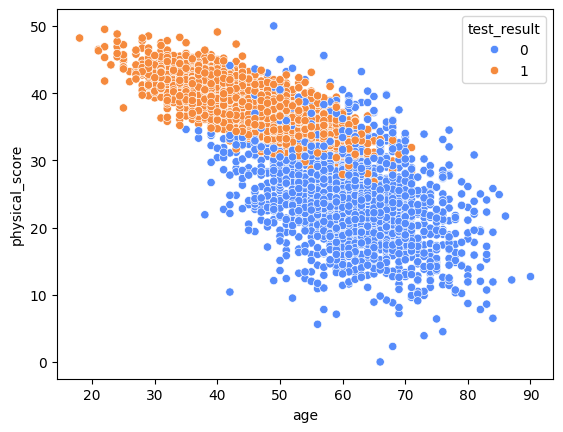

In [155]:
#`age` vs. `physical_score` using the labels as `hue.`
scatter, ax = plt.subplots()
ax = sns.scatterplot(x = 'age', y = 'physical_score', data = data, hue = 'test_result')
ax.set_xlabel('age')
ax.set_ylabel('physical_score')
plt.show()

What can you conclude about the participants from this scatterplot?
* This shows that the younger participants scored better during the physical exam and were able to hear higher frequencies on an audio test.

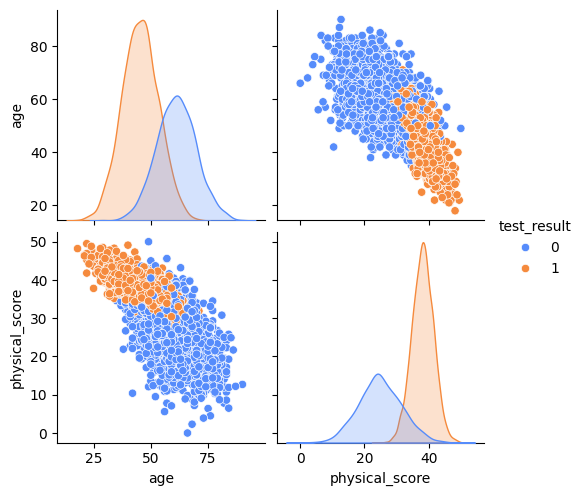

In [5]:
# pairplot
fig = sns.pairplot( data, hue = "test_result")
plt.show()

The physical score seems most correlated with the test result and the age feature is inversely correlated with test result. 

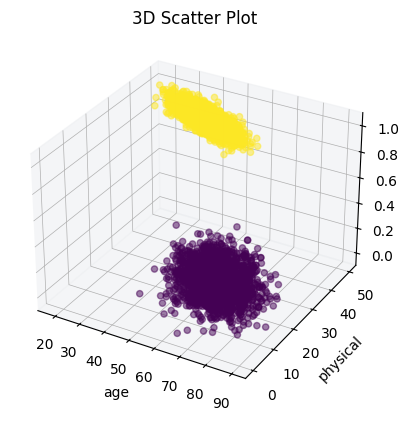

In [179]:
# 3d Scatterplot
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(data['age'], data['physical_score'], data['test_result'], c = data['test_result'], cmap = 'viridis', alpha=0.5)

ax.set_zlim(-0.1, 1.1)

ax.set_xlabel('age')
ax.set_ylabel('physical')
ax.set_title('3D Scatter Plot')

plt.show()

What can you conclude from this plot?
* The groups of individuals that pass the audio test are separate from those pass in a way creates categories. There also appears to be a pattern in among those who pass the audio test, as apposed to those who didn't.

In [191]:
# ALWAYS SPLIT THEN SCALE
X = data[['age', 'physical_score']].values
y = data['test_result'].values

X_train,X_test,Y_train,Y_test = train_test_split(X, y, test_size=0.2, stratify= y)

sX_train = scaler.fit_transform(X_train)
sX_test = scaler.fit_transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
log_reg = LogisticRegression()
log_reg.fit(sX_train, Y_train)

#Lo
y_pred = log_reg.predict(sX_test)
coefficients = log_reg.coef_[0]
accuracy1 = log_reg.score(X_test, Y_test)
accuracy2 = accuracy_score(Y_test, y_pred)
print(coefficients, accuracy1, accuracy2)

#interpret coefficients

[-0.82458515  3.54356588] 0.619 0.918


Interpreting Coefficients from Logistic Regression model
* The negative coefficient from age vs. test results shows that as age increases, test results decrease
* the positive coefficient from physical score vs. test result shows the better physical score and participant achieved, the more likely they were to increase